# Эксперимент 3: розничные продажи M5

Этот ноутбук является шаблоном для эксперимента с продажами M5. Естественные ограничения здесь — иерархические суммы, неотрицательность и доли товаров.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.constraints import m5_sales_constraints
from src.metrics import compare_forecasts
from src.stat_tests import paired_forecast_tests, paired_loss_improvements
from src.nlcr import reconcile_many
from src.plotting import (
    plot_constraint_violations,
    plot_paired_improvement_distributions,
    plot_relative_improvements,
    plot_win_rates,
)

RESULTS_DIR = PROJECT_ROOT / "results"
(RESULTS_DIR / "tables").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)

## Заготовка данных

In [2]:
def make_demo_m5_data(n=420, n_items=3, seed=13):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    sales = []

    for i in range(n_items):
        level = 20 + 8 * i
        weekly = 4 * np.sin(2 * np.pi * (t + 2 * i) / 7)
        trend = 0.015 * t * (i + 1)
        noise = rng.normal(0, 2 + i, n)
        item = np.maximum(level + weekly + trend + noise, 0.1)
        sales.append(item)

    sales = np.column_stack(sales)
    total = sales.sum(axis=1)
    shares = sales / total[:, None]

    data = pd.DataFrame(sales, columns=[f"sales_{i}" for i in range(n_items)])
    data["total_sales"] = total
    for i in range(n_items):
        data[f"share_{i}"] = shares[:, i]
    return data


processed_path = PROJECT_ROOT / "data" / "processed" / "m5" / "m5_selected_hierarchy.parquet"

if processed_path.exists():
    data = pd.read_parquet(processed_path)
    sales_columns = [col for col in data.columns if col.startswith("sales_")]
    n_items = len(sales_columns)
    data_source = f"processed: {processed_path.relative_to(PROJECT_ROOT)}"
else:
    n_items = 3
    data = make_demo_m5_data(n_items=n_items)
    data_source = "demo generator; run scripts/download_data.py m5 and scripts/prepare_data.py m5 for real data"

constraints = m5_sales_constraints(n_items)
columns = constraints.names
data = data[columns].copy()

print(data_source)
data.head()

processed: data/processed/m5/m5_selected_hierarchy.parquet


,sales_0,sales_1,sales_2,total_sales,share_0,share_1,share_2
0,107.0,42.0,19.0,168.0,0.636905,0.250000,0.113095
1,182.0,36.0,14.0,232.0,0.784483,0.155172,0.060345
2,47.0,30.0,10.0,87.0,0.540230,0.344828,0.114943
3,47.0,23.0,8.0,78.0,0.602564,0.294872,0.102564
4,62.0,27.0,8.0,97.0,0.639175,0.278351,0.082474


## Базовые прогнозы

Базовая модель использует независимые скользящие средние. В итоговом эксперименте M5 этот блок следует заменить сезонным наивным прогнозом и признаковой моделью с лагами, ценами и календарными переменными.

In [3]:
def rolling_mean_baseline(frame, test_start, windows):
    rows = []
    for t in range(test_start, len(frame)):
        rows.append([frame[col].iloc[t - window:t].mean() for col, window in zip(frame.columns, windows)])
    return pd.DataFrame(rows, columns=frame.columns, index=frame.index[test_start:])


test_size = 84
test_start = len(data) - test_size
windows = [7, 14, 21, 28, 10, 16, 22]
calibration_start = max(windows)

calibration_base = rolling_mean_baseline(data[columns], calibration_start, windows)
y_calibration_true = data.iloc[calibration_start:test_start].reset_index(drop=True)
y_calibration_base = calibration_base.iloc[:test_start - calibration_start].reset_index(drop=True)
calibration_errors = y_calibration_true - y_calibration_base

y_true = data.iloc[test_start:].reset_index(drop=True)
y_base = rolling_mean_baseline(data[columns], test_start, windows).reset_index(drop=True)
y_base.head()

,sales_0,sales_1,sales_2,total_sales,share_0,share_1,share_2
0,51.285714,36.000000,38.619048,121.678571,0.422142,0.298821,0.304795
1,51.142857,35.642857,38.095238,121.392857,0.428732,0.297903,0.304490
2,51.571429,35.785714,37.428571,121.964286,0.431513,0.298640,0.298411
3,55.428571,35.857143,37.238095,122.428571,0.427551,0.300060,0.293105
4,57.714286,35.857143,36.523810,122.857143,0.427926,0.300849,0.289169


## Проекция NLCR и оценивание

In [4]:
METHODS = ("ols", "wls", "shr")
y_reconciled_by_method = {}
failed_by_method = {}

for method in METHODS:
    kwargs = {} if method == "ols" else {"errors": calibration_errors}
    y_reconciled_by_method[method], failed_by_method[method] = reconcile_many(
        y_base,
        constraints,
        method=method,
        **kwargs,
    )

failed_by_method

# Keep the OLS projection under the historical variable name for compatibility
# with existing narrative cells and quick inspection.
y_reconciled = y_reconciled_by_method["ols"]
y_reconciled.head()

,sales_0,sales_1,sales_2,total_sales,share_0,share_1,share_2
0,50.229201,34.943497,37.562419,122.735116,0.409249,0.284707,0.306045
1,50.270891,34.770857,37.223128,122.264876,0.411164,0.284390,0.304447
2,50.866129,35.080381,36.723127,122.669637,0.414659,0.285974,0.299366
3,53.904651,34.333469,35.714274,123.952394,0.434882,0.276989,0.288129
4,55.904557,34.047804,34.714333,124.666694,0.448432,0.273111,0.278457


In [5]:
metric_tables = []
stat_test_tables = []
loss_improvement_tables = []

for method, y_method in y_reconciled_by_method.items():
    method_metrics = compare_forecasts(y_true, y_base, y_method, constraints)
    method_metrics["p_reconciled_better"] = method_metrics.attrs["p_reconciled_better"]
    method_metrics["method"] = method_metrics["forecast"].where(method_metrics["forecast"] == "base", method)
    method_metrics = method_metrics[method_metrics["forecast"] != "base"]
    metric_tables.append(method_metrics)

    method_stat_tests = paired_forecast_tests(y_true, y_base, y_method)
    method_stat_tests.insert(0, "method", method)
    stat_test_tables.append(method_stat_tests)

    method_loss_improvements = paired_loss_improvements(y_true, y_base, y_method)
    method_loss_improvements.insert(0, "method", method)
    loss_improvement_tables.append(method_loss_improvements)

base_metrics = compare_forecasts(y_true, y_base, y_reconciled_by_method["ols"], constraints)
base_metrics = base_metrics[base_metrics["forecast"] == "base"].copy()
base_metrics["p_reconciled_better"] = pd.NA
base_metrics["method"] = "base"

metrics = pd.concat([base_metrics, *metric_tables], ignore_index=True)
metrics.to_csv(RESULTS_DIR / "tables" / "m5_sales_metrics.csv", index=False)

stat_tests = pd.concat(stat_test_tables, ignore_index=True)
stat_tests.to_csv(RESULTS_DIR / "tables" / "m5_sales_stat_tests.csv", index=False)

loss_improvements = pd.concat(loss_improvement_tables, ignore_index=True)
loss_improvements.to_csv(RESULTS_DIR / "tables" / "m5_sales_loss_improvements.csv", index=False)

display(stat_tests)
metrics

,method,metric,base_loss,nlcr_loss,mean_improvement,relative_improvement_pct,win_rate,wilcoxon_stat,wilcoxon_p,sign_p,bootstrap_ci_low,bootstrap_ci_high,n_observations,n_non_ties
0,ols,mae,10.001063,9.986216,0.014847,0.148457,0.464286,1814.0,4.485469e-01,7.773977e-01,-0.049475,0.071942,84,84
1,ols,rmse,15.722089,15.678626,0.043463,0.276444,1.000000,3570.0,8.553276e-16,5.169879e-26,0.023816,0.071243,84,84
2,ols,smape,0.226750,0.228438,-0.001688,-0.744394,0.416667,1589.0,8.089725e-01,9.494318e-01,-0.004856,0.000676,84,84
3,wls,mae,10.001063,9.949526,0.051537,0.515316,0.630952,2120.0,6.758450e-02,1.069159e-02,-0.008164,0.134830,84,84
4,wls,rmse,15.722089,15.592935,0.129154,0.821483,0.630952,2175.0,4.098985e-02,1.069159e-02,0.016889,0.314807,84,84
5,wls,smape,0.226750,0.226365,0.000384,0.169477,0.535714,1890.0,3.197934e-01,2.928234e-01,-0.000512,0.001583,84,84
6,shr,mae,10.001063,10.005042,-0.003979,-0.039787,0.511905,1929.0,2.603691e-01,4.566012e-01,-0.169448,0.273663,84,84
7,shr,rmse,15.722089,15.663551,0.058538,0.372327,0.500000,1891.0,3.182006e-01,5.433988e-01,-0.200668,0.548756,84,84
8,shr,smape,0.226750,0.227649,-0.000899,-0.396447,0.464286,1685.0,6.721933e-01,7.773977e-01,-0.002531,0.001917,84,84


,forecast,mae,rmse,smape,constraint_violation,p_reconciled_better,method
0,base,10.001063,18.606172,0.226750,4.334020e+00,<NA>,base
1,nlcr,9.986216,18.577640,0.228438,1.176157e-14,1.0,ols
2,nlcr,9.949526,18.483705,0.226365,3.091769e-12,0.630952,wls
3,nlcr,10.005042,18.619443,0.227649,1.207914e-12,0.5,shr


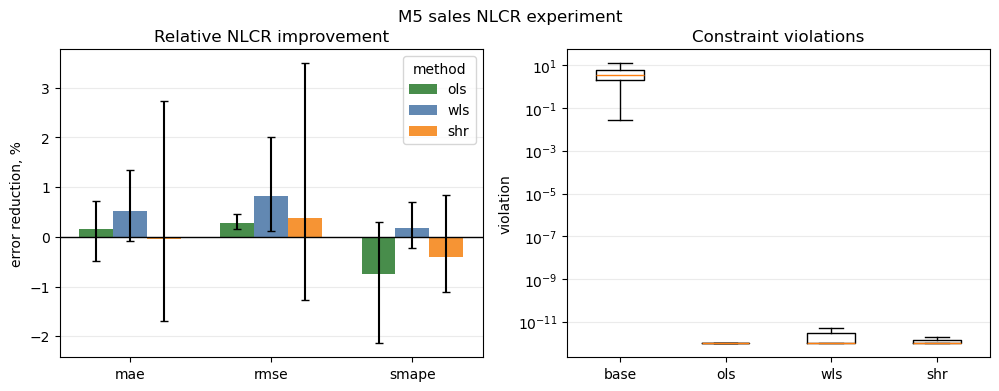

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_relative_improvements(stat_tests, ax=axes[0])
plot_constraint_violations(y_base, y_reconciled_by_method, constraints, ax=axes[1])
fig.suptitle("M5 sales NLCR experiment")
fig.savefig(RESULTS_DIR / "figures" / "m5_sales_experiment.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

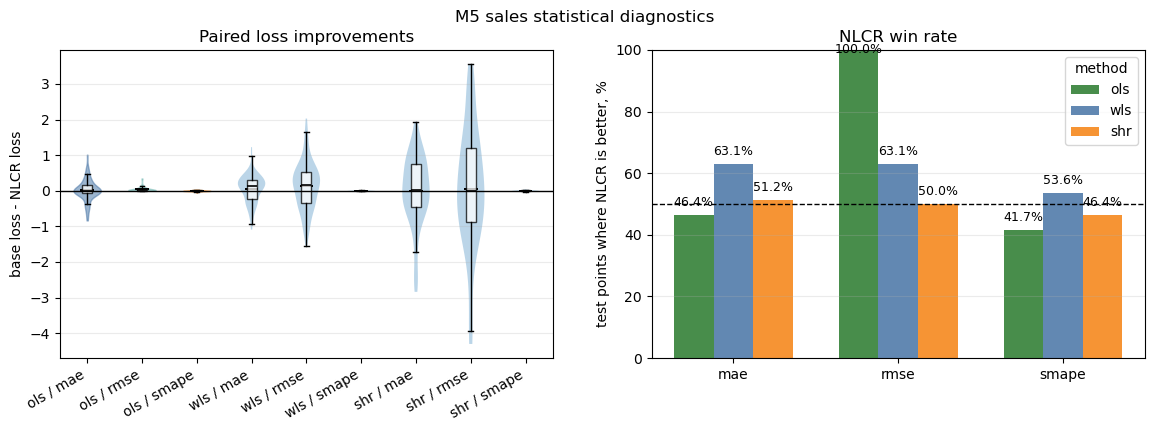

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_paired_improvement_distributions(loss_improvements, ax=axes[0])
plot_win_rates(stat_tests, ax=axes[1])
fig.suptitle("M5 sales statistical diagnostics")
fig.savefig(RESULTS_DIR / "figures" / "m5_sales_stat_tests.png", dpi=200, bbox_inches="tight")
display(fig)
plt.close(fig)

## Выводы по результатам эксперимента

- NLCR устраняет несогласованность иерархии продаж: mean violation снижается с `4.334` до порядка `1e-12`.
- Лучший результат дал `wls`: MAE `10.001 -> 9.950`, RMSE `18.606 -> 18.484`, SMAPE `0.2268 -> 0.2264`; улучшение небольшое, но положительное по всем метрикам.
- `ols` стабильно улучшает RMSE, но ухудшает SMAPE; `shr` не дает устойчивого выигрыша. Наиболее надежным вариантом для этого subset оказался диагональный WLS.
- Вероятная причина малого эффекта: выбранная M5-иерархия компактна, а rolling mean baseline уже частично сохраняет связь между item-sales, total-sales и shares.